<a href="https://colab.research.google.com/github/claraanjelitakd/Comparison-of-ResNet50-and-YOLOv8-for-Multi-Class-/blob/main/comparison_of_resnet50_and_yolov8_for_multi_class_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install ultralytics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.5 MB/s eta 0:00:00a 0:00:01


In [ ]:
import os
import cv2
import glob
import yaml
import shutil
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from ultralytics import YOLO

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


E0000 00:00:1779701407.113274      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779701407.225876      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779701408.295282      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779701408.295321      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779701408.295324      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779701408.295326      57 computation_placer.cc:177] computation placer already registered. Please check linka

In [ ]:
BASE_PATH = "/kaggle/input/datasets/ahmedsorour1/mri-for-brain-tumor-with-bounding-boxes"

SOURCE_FOLDERS = [
    f"{BASE_PATH}/Train",
    f"{BASE_PATH}/Val"
]

CLASS_NAMES = ["Glioma", "Meningioma", "No Tumor", "Pituitary"]

label_map = {
    "Glioma": 0,
    "Meningioma": 1,
    "No Tumor": 2,
    "Pituitary": 3
}

idx_to_label = {v: k for k, v in label_map.items()}

IMG_SIZE = (224, 224)

print(CLASS_NAMES)

['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']


In [ ]:
def collect_all_images():
    image_paths = []
    labels = []

    for source in SOURCE_FOLDERS:
        for class_name in CLASS_NAMES:
            patterns = [
                f"{source}/{class_name}/images/*.jpg",
                f"{source}/{class_name}/images/*.png",
                f"{source}/{class_name}/*.jpg",
                f"{source}/{class_name}/*.png"
            ]

            class_images = []

            for pattern in patterns:
                class_images.extend(glob.glob(pattern))

            for img_path in class_images:
                image_paths.append(img_path)
                labels.append(label_map[class_name])

    return np.array(image_paths), np.array(labels)


all_image_paths, all_labels = collect_all_images()

print("Total images:", len(all_image_paths))
print(pd.Series(all_labels).value_counts().sort_index())

Total images: 5249
0    1289
1    1589
2     811
3    1560
Name: count, dtype: int64


In [ ]:
train_paths, test_paths, y_train, y_test = train_test_split(
    all_image_paths,
    all_labels,
    test_size=0.2,
    random_state=42,
    stratify=all_labels
)

print("Train:", len(train_paths))
print("Test :", len(test_paths))

print("\nTrain distribution:")
print(pd.Series(y_train).value_counts().sort_index())

print("\nTest distribution:")
print(pd.Series(y_test).value_counts().sort_index())

Train: 4199
Test : 1050

Train distribution:
0    1031
1    1271
2     649
3    1248
Name: count, dtype: int64

Test distribution:
0    258
1    318
2    162
3    312
Name: count, dtype: int64


In [ ]:
def load_images(image_paths, img_size=(224, 224)):
    X = []

    for img_path in image_paths:
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)

        X.append(img)

    return np.array(X, dtype=np.float32)


X_train = load_images(train_paths, IMG_SIZE)
X_test = load_images(test_paths, IMG_SIZE)

X_train_resnet = preprocess_input(X_train.copy())
X_test_resnet = preprocess_input(X_test.copy())

print("X_train:", X_train_resnet.shape)
print("X_test :", X_test_resnet.shape)

X_train: (4199, 224, 224, 3)
X_test : (1050, 224, 224, 3)


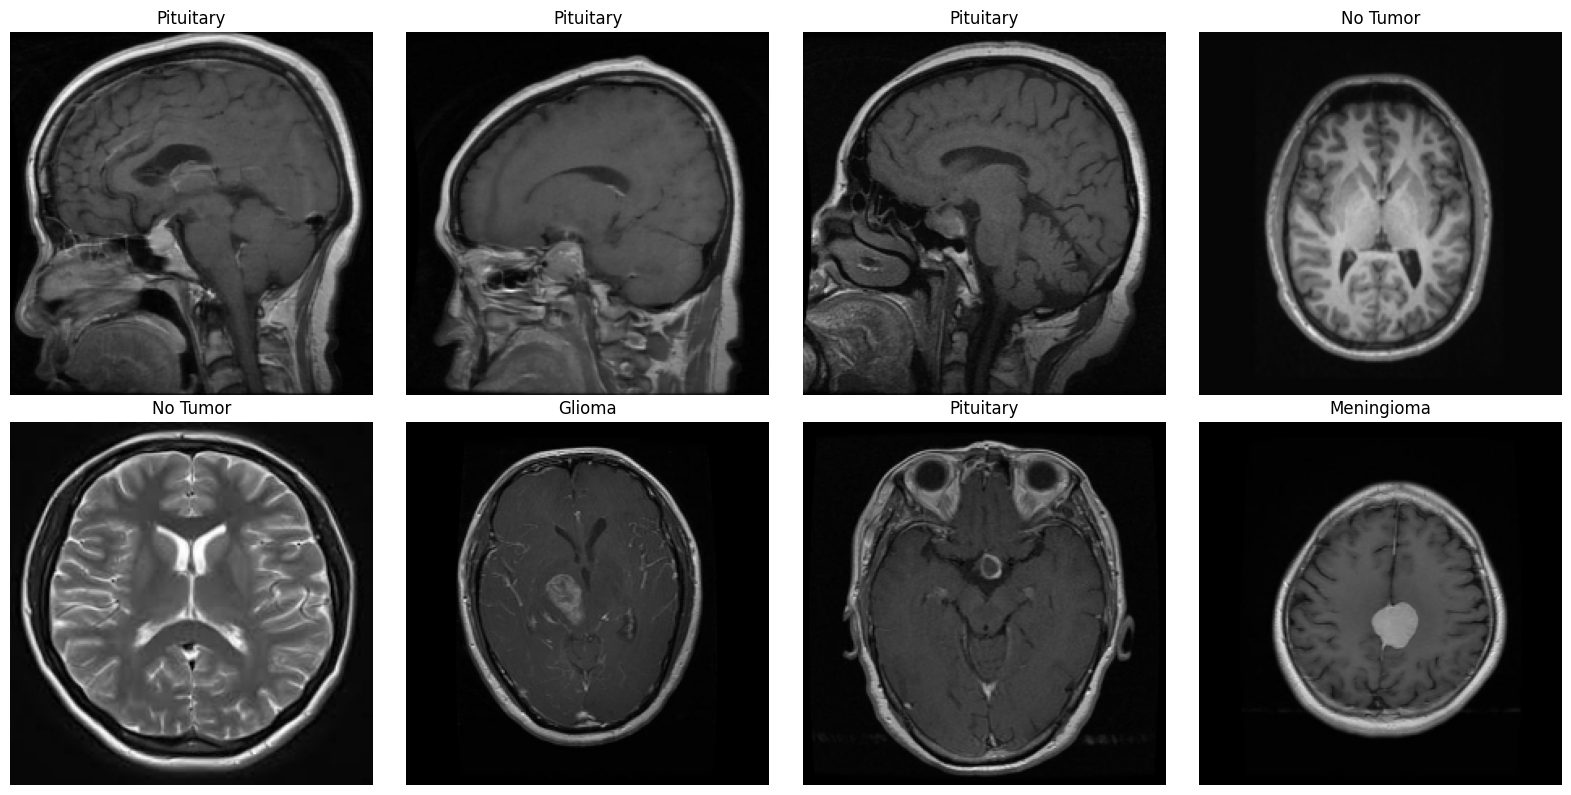

In [ ]:
plt.figure(figsize=(16, 8))

sample_idx = random.sample(range(len(X_train)), 8)

for i, idx in enumerate(sample_idx):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_train[idx].astype("uint8"))
    plt.title(idx_to_label[y_train[idx]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
base_resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_resnet.trainable = False

resnet_model = models.Sequential([
    base_resnet,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),

    layers.Dense(256, activation="relu"),
    layers.Dropout(0.4),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(4, activation="softmax")
])

resnet_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

resnet_model.summary()

I0000 00:00:1779701522.549466      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779701522.552398      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,153,860 (92.14 MB)

 Trainable params: 562,052 (2.14 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [ ]:
callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7
    )
]

history_resnet = resnet_model.fit(
    X_train_resnet,
    y_train,
    validation_data=(X_test_resnet, y_test),
    epochs=20,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/20


I0000 00:00:1779701540.134788     164 service.cc:152] XLA service 0x7f9fc4054950 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779701540.134826     164 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779701540.134830     164 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779701542.193329     164 cuda_dnn.cc:529] Loaded cuDNN version 91002


  1/132 ━━━━━━━━━━━━━━━━━━━━ 34:57 16s/step - accuracy: 0.2500 - loss: 2.0712

I0000 00:00:1779701548.786607     164 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


132/132 ━━━━━━━━━━━━━━━━━━━━ 45s 218ms/step - accuracy: 0.4850 - loss: 1.3289 - val_accuracy: 0.8505 - val_loss: 0.5084 - learning_rate: 1.0000e-04
Epoch 2/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - accuracy: 0.7926 - loss: 0.5516 - val_accuracy: 0.8952 - val_loss: 0.3157 - learning_rate: 1.0000e-04
Epoch 3/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 14s 109ms/step - accuracy: 0.8423 - loss: 0.4178 - val_accuracy: 0.9181 - val_loss: 0.2407 - learning_rate: 1.0000e-04
Epoch 4/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 15s 113ms/step - accuracy: 0.8655 - loss: 0.3498 - val_accuracy: 0.9305 - val_loss: 0.1996 - learning_rate: 1.0000e-04
Epoch 5/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 15s 117ms/step - accuracy: 0.9061 - loss: 0.2642 - val_accuracy: 0.9324 - val_loss: 0.1790 - learning_rate: 1.0000e-04
Epoch 6/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 16s 125ms/step - accuracy: 0.9140 - loss: 0.2311 - val_accuracy: 0.9419 - val_loss: 0.1612 - learning_rate: 1.0000e-04
Epoch 7/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 17s 129ms/step - 

In [ ]:
def calculate_specificity(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    specificity_list = []

    for i in range(len(cm)):
        TP = cm[i, i]
        FN = np.sum(cm[i, :]) - TP
        FP = np.sum(cm[:, i]) - TP
        TN = np.sum(cm) - (TP + FN + FP)

        specificity = TN / (TN + FP + 1e-7)
        specificity_list.append(specificity)

    return np.mean(specificity_list)


def evaluate_multiclass(model_name, y_true, y_pred, y_prob):
    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    specificity = calculate_specificity(y_true, y_pred)

    y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3])

    roc_auc = roc_auc_score(
        y_true_bin,
        y_prob,
        multi_class="ovr"
    )

    print(f"\n===== {model_name} =====")
    print("Accuracy    :", accuracy)
    print("Precision   :", precision)
    print("Recall      :", recall)
    print("F1-Score    :", f1)
    print("Specificity :", specificity)
    print("ROC-AUC     :", roc_auc)

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=CLASS_NAMES,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(7, 6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "Specificity": specificity,
        "ROC-AUC": roc_auc
    }


===== ResNet50 =====
Accuracy    : 0.9666666666666667
Precision   : 0.9667754979889591
Recall      : 0.9666666666666667
F1-Score    : 0.9666143433466402
Specificity : 0.9884038978013826
ROC-AUC     : 0.9972392309214118

Classification Report:
              precision    recall  f1-score   support

      Glioma       0.98      0.95      0.96       258
  Meningioma       0.94      0.95      0.95       318
    No Tumor       0.98      0.97      0.98       162
   Pituitary       0.97      1.00      0.99       312

    accuracy                           0.97      1050
   macro avg       0.97      0.97      0.97      1050
weighted avg       0.97      0.97      0.97      1050



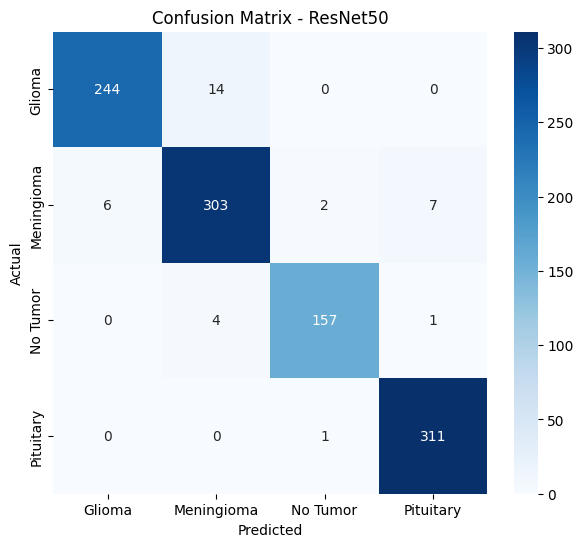

In [ ]:
resnet_prob = resnet_model.predict(X_test_resnet, verbose=0)
resnet_pred = np.argmax(resnet_prob, axis=1)

resnet_result = evaluate_multiclass(
    "ResNet50",
    y_test,
    resnet_pred,
    resnet_prob
)

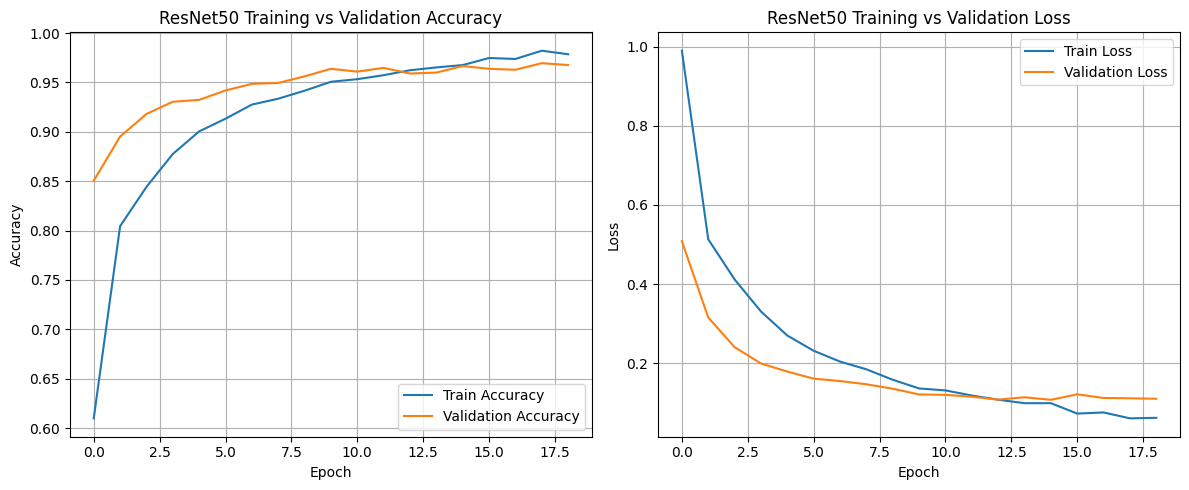

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_resnet.history["accuracy"], label="Train Accuracy")
plt.plot(history_resnet.history["val_accuracy"], label="Validation Accuracy")
plt.title("ResNet50 Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history_resnet.history["loss"], label="Train Loss")
plt.plot(history_resnet.history["val_loss"], label="Validation Loss")
plt.title("ResNet50 Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

In [ ]:
YOLO_SPLIT_PATH = "/kaggle/working/yolo_80_20_dataset"

for split in ["train", "test"]:
    for class_name in CLASS_NAMES:
        os.makedirs(f"{YOLO_SPLIT_PATH}/{split}/{class_name}/images", exist_ok=True)
        os.makedirs(f"{YOLO_SPLIT_PATH}/{split}/{class_name}/labels", exist_ok=True)


def copy_yolo_files(paths, labels, split_name):
    for img_path, label_idx in zip(paths, labels):
        class_name = idx_to_label[label_idx]

        img_name = os.path.basename(img_path)

        label_path = img_path.replace("/images/", "/labels/")
        label_path = os.path.splitext(label_path)[0] + ".txt"

        dst_img = f"{YOLO_SPLIT_PATH}/{split_name}/{class_name}/images/{img_name}"
        dst_label = f"{YOLO_SPLIT_PATH}/{split_name}/{class_name}/labels/{os.path.splitext(img_name)[0]}.txt"

        shutil.copy(img_path, dst_img)

        if os.path.exists(label_path):
            shutil.copy(label_path, dst_label)
        else:
            open(dst_label, "w").close()


copy_yolo_files(train_paths, y_train, "train")
copy_yolo_files(test_paths, y_test, "test")

print("YOLO dataset 80:20 selesai dibuat.")

YOLO dataset 80:20 selesai dibuat.


In [ ]:
yolo_yaml = {
    "train": f"{YOLO_SPLIT_PATH}/train",
    "val": f"{YOLO_SPLIT_PATH}/test",
    "nc": 4,
    "names": CLASS_NAMES
}

yaml_path = "/kaggle/working/brain_tumor_yolo_80_20.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(yolo_yaml, f, default_flow_style=False)

print("YAML:", yaml_path)

YAML: /kaggle/working/brain_tumor_yolo_80_20.yaml


In [ ]:
if torch.cuda.is_available():
    target_device = 0
    print("GPU:", torch.cuda.get_device_name(0))
else:
    target_device = "cpu"
    print("GPU tidak aktif")

yolo_model = YOLO("yolov8n.pt")

yolo_train_result = yolo_model.train(
    data=yaml_path,
    epochs=20,
    imgsz=416,
    batch=8,
    device=target_device,
    workers=2,
    project="/kaggle/working/tumor_detection_80_20",
    name="yolov8_resnet_comparison",
    exist_ok=True
)

GPU: Tesla T4
Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/brain_tumor_yolo_80_20.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8_resnet_comparison, nbs=64, nms=False, opset=None, optimize=False, optimi

In [ ]:
best_yolo_path = "/kaggle/working/tumor_detection_80_20/yolov8_resnet_comparison/weights/best.pt"

best_yolo = YOLO(best_yolo_path)

print("Loaded:", best_yolo_path)

Loaded: /kaggle/working/tumor_detection_80_20/yolov8_resnet_comparison/weights/best.pt


In [ ]:
yolo_metrics = best_yolo.val(data=yaml_path)

print("YOLOv8 Metrics")
print("Precision :", yolo_metrics.box.mp)
print("Recall    :", yolo_metrics.box.mr)
print("mAP@50    :", yolo_metrics.box.map50)
print("mAP@50-95 :", yolo_metrics.box.map)

Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 728.2±164.4 MB/s, size: 21.7 KB)
val: Scanning /kaggle/working/yolo_80_20_dataset/test/Glioma/labels.cache... 1050 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1050/1050 440.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 66/66 11.1it/s 6.0s0.2s
                   all       1050       1196      0.937       0.92      0.959       0.75
                Glioma        258        307      0.889      0.835       0.91      0.685
            Meningioma        317        326      0.979      0.978      0.992      0.843
              No Tumor        161        161      0.986          1      0.991      0.778
             Pituitary        366        402      0.896      0.868      0.942      0.695
Speed: 0.5ms prep


===== YOLOv8 =====
Accuracy    : 0.98
Precision   : 0.9805684935035471
Recall      : 0.98
F1-Score    : 0.9799910978688889
Specificity : 0.9934187189265496
ROC-AUC     : 0.9872511372970096

Classification Report:
              precision    recall  f1-score   support

      Glioma       1.00      0.95      0.97       258
  Meningioma       0.99      0.98      0.99       318
    No Tumor       0.95      1.00      0.97       162
   Pituitary       0.97      0.99      0.98       312

    accuracy                           0.98      1050
   macro avg       0.98      0.98      0.98      1050
weighted avg       0.98      0.98      0.98      1050



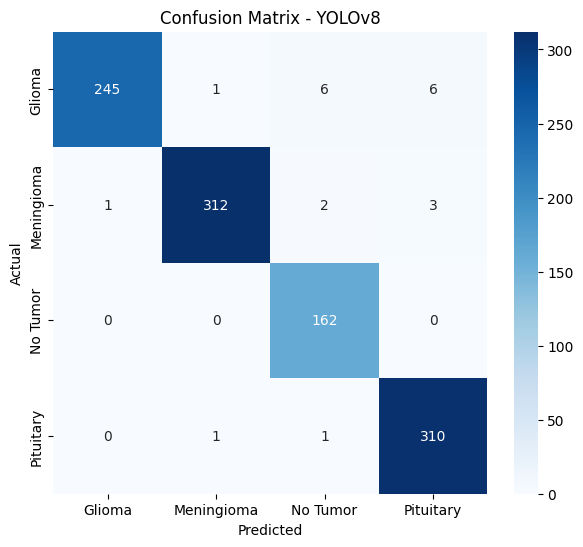

In [ ]:
def predict_yolo_image_level(model, image_paths):
    y_pred = []
    y_prob = []

    for img_path in image_paths:
        result = model.predict(
            source=img_path,
            conf=0.25,
            verbose=False
        )[0]

        probs = np.zeros(4)

        if len(result.boxes) > 0:
            confs = result.boxes.conf.cpu().numpy()
            classes = result.boxes.cls.cpu().numpy().astype(int)

            best_idx = np.argmax(confs)
            pred_class = classes[best_idx]

            probs[pred_class] = confs[best_idx]
            y_pred.append(pred_class)
        else:
            pred_class = label_map["No Tumor"]
            probs[pred_class] = 1.0
            y_pred.append(pred_class)

        probs = probs / probs.sum()
        y_prob.append(probs)

    return np.array(y_pred), np.array(y_prob)


yolo_pred, yolo_prob = predict_yolo_image_level(best_yolo, test_paths)

yolo_result = evaluate_multiclass(
    "YOLOv8",
    y_test,
    yolo_pred,
    yolo_prob
)

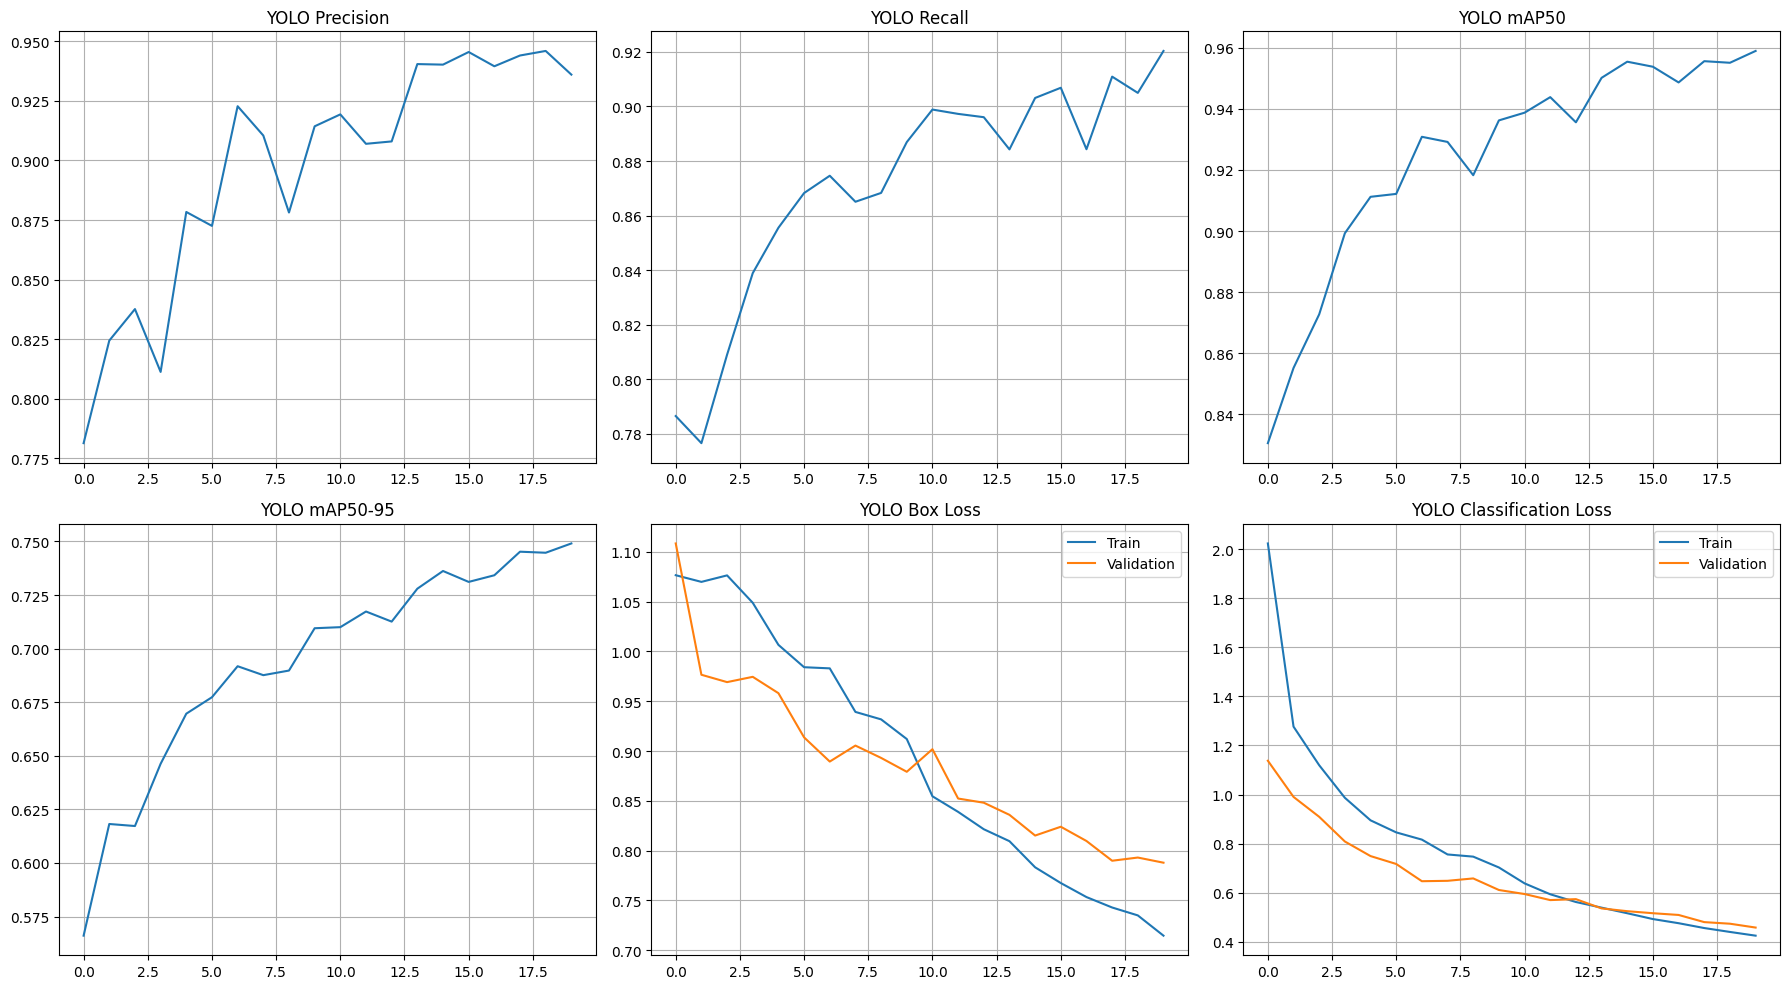

In [ ]:
yolo_csv_path = "/kaggle/working/tumor_detection_80_20/yolov8_resnet_comparison/results.csv"

if os.path.exists(yolo_csv_path):
    yolo_df = pd.read_csv(yolo_csv_path)
    yolo_df.columns = yolo_df.columns.str.strip()

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    axes[0, 0].plot(yolo_df["metrics/precision(B)"])
    axes[0, 0].set_title("YOLO Precision")
    axes[0, 0].grid()

    axes[0, 1].plot(yolo_df["metrics/recall(B)"])
    axes[0, 1].set_title("YOLO Recall")
    axes[0, 1].grid()

    axes[0, 2].plot(yolo_df["metrics/mAP50(B)"])
    axes[0, 2].set_title("YOLO mAP50")
    axes[0, 2].grid()

    axes[1, 0].plot(yolo_df["metrics/mAP50-95(B)"])
    axes[1, 0].set_title("YOLO mAP50-95")
    axes[1, 0].grid()

    axes[1, 1].plot(yolo_df["train/box_loss"], label="Train")
    axes[1, 1].plot(yolo_df["val/box_loss"], label="Validation")
    axes[1, 1].set_title("YOLO Box Loss")
    axes[1, 1].legend()
    axes[1, 1].grid()

    axes[1, 2].plot(yolo_df["train/cls_loss"], label="Train")
    axes[1, 2].plot(yolo_df["val/cls_loss"], label="Validation")
    axes[1, 2].set_title("YOLO Classification Loss")
    axes[1, 2].legend()
    axes[1, 2].grid()

    plt.tight_layout()
    plt.show()

In [ ]:
df_results = pd.DataFrame([
    resnet_result,
    yolo_result
])

display(df_results)

,Model,Accuracy,Precision,Recall,F1-Score,Specificity,ROC-AUC
0,ResNet50,0.966667,0.966775,0.966667,0.966614,0.988404,0.997239
1,YOLOv8,0.980000,0.980568,0.980000,0.979991,0.993419,0.987251


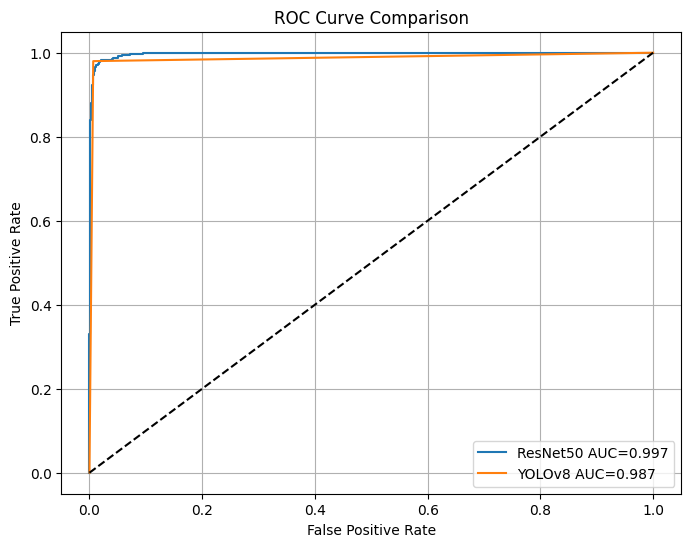

In [ ]:
y_true_bin = label_binarize(y_test, classes=[0, 1, 2, 3])

models_prob = {
    "ResNet50": resnet_prob,
    "YOLOv8": yolo_prob
}

plt.figure(figsize=(8, 6))

for model_name, probs in models_prob.items():
    fpr, tpr, _ = roc_curve(
        y_true_bin.ravel(),
        probs.ravel()
    )

    roc_auc_value = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} AUC={roc_auc_value:.3f}"
    )

plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# ==========================================
# SAMPLE PREDICTION COMPARISON
# ==========================================

sample_indices = random.sample(range(len(test_paths)), 12)

prediction_results = []

for idx in sample_indices:

    img_path = test_paths[idx]

    actual_class = idx_to_label[y_test[idx]]

    # ======================================
    # RESNET50 PREDICTION
    # ======================================
    resnet_class = idx_to_label[resnet_pred[idx]]

    resnet_result_text = (
        "Correct"
        if actual_class == resnet_class
        else "Wrong"
    )

    # ======================================
    # YOLO PREDICTION
    # ======================================
    yolo_class = idx_to_label[yolo_pred[idx]]

    yolo_result_text = (
        "Correct"
        if actual_class == yolo_class
        else "Wrong"
    )

    prediction_results.append({
        "Image": os.path.basename(img_path),

        "Actual Class": actual_class,

        "ResNet50 Prediction": resnet_class,
        "ResNet50 Result": resnet_result_text,

        "YOLOv8 Prediction": yolo_class,
        "YOLOv8 Result": yolo_result_text
    })

df_prediction = pd.DataFrame(prediction_results)

display(df_prediction)

,Image,Actual Class,ResNet50 Prediction,ResNet50 Result,YOLOv8 Prediction,YOLOv8 Result
0,gg (643).jpg,Glioma,Glioma,Correct,Glioma,Correct
1,p (92).jpg,Pituitary,Pituitary,Correct,Pituitary,Correct
2,gg (817).jpg,Glioma,Glioma,Correct,Glioma,Correct
3,Tr-me_0387.jpg,Meningioma,Meningioma,Correct,Meningioma,Correct
4,gg (396).jpg,Glioma,Glioma,Correct,Glioma,Correct
5,Tr-me_0611.jpg,Meningioma,Meningioma,Correct,Meningioma,Correct
6,gg (382).jpg,Glioma,Glioma,Correct,Glioma,Correct
7,Tr-gl_0461.jpg,Glioma,Glioma,Correct,Glioma,Correct
8,Tr-pi_0071.jpg,Pituitary,Pituitary,Correct,Pituitary,Correct
9,Tr-no_0071.jpg,No Tumor,No Tumor,Correct,No Tumor,Correct


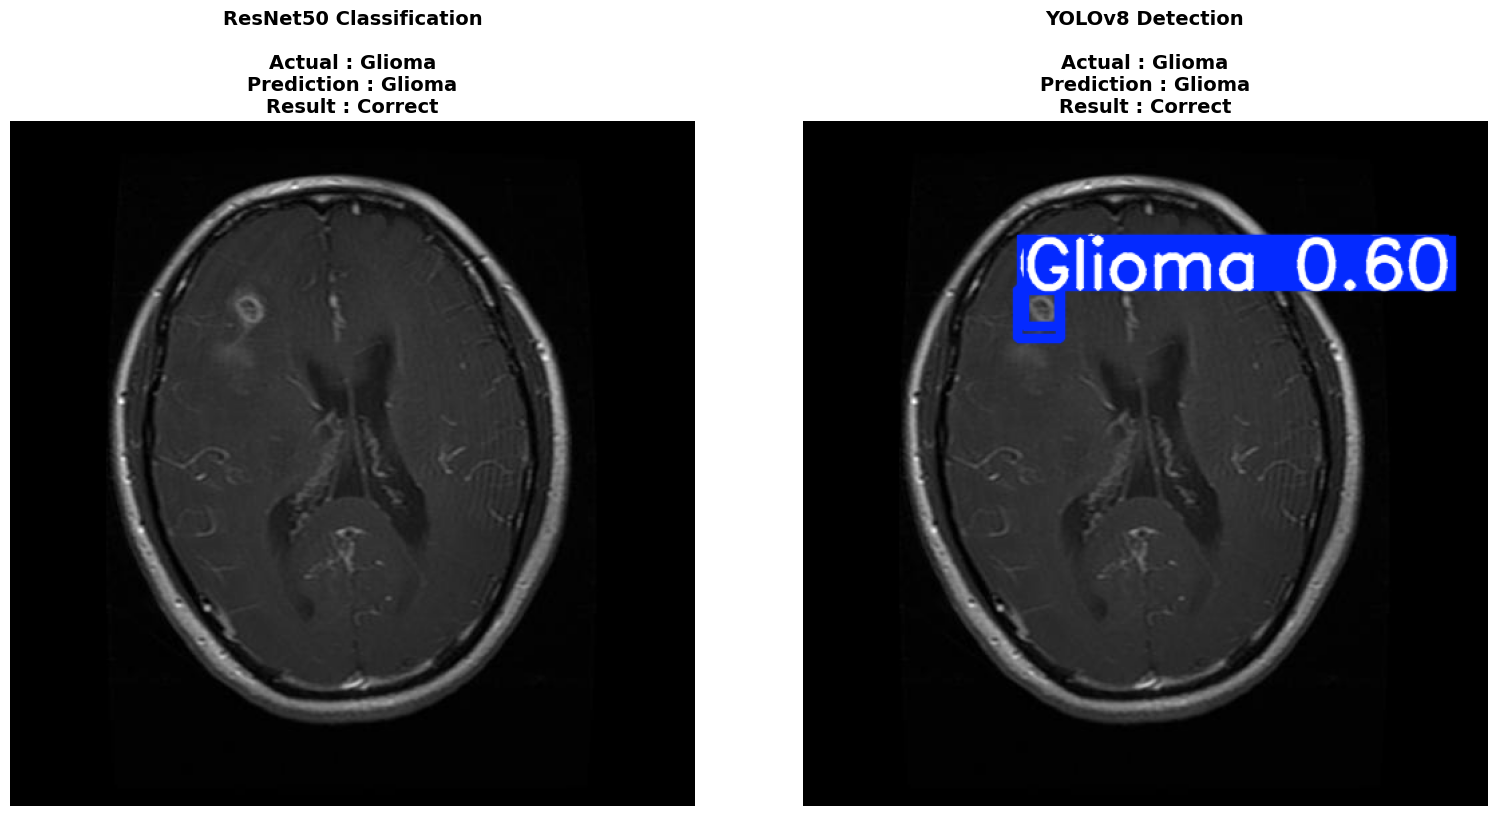

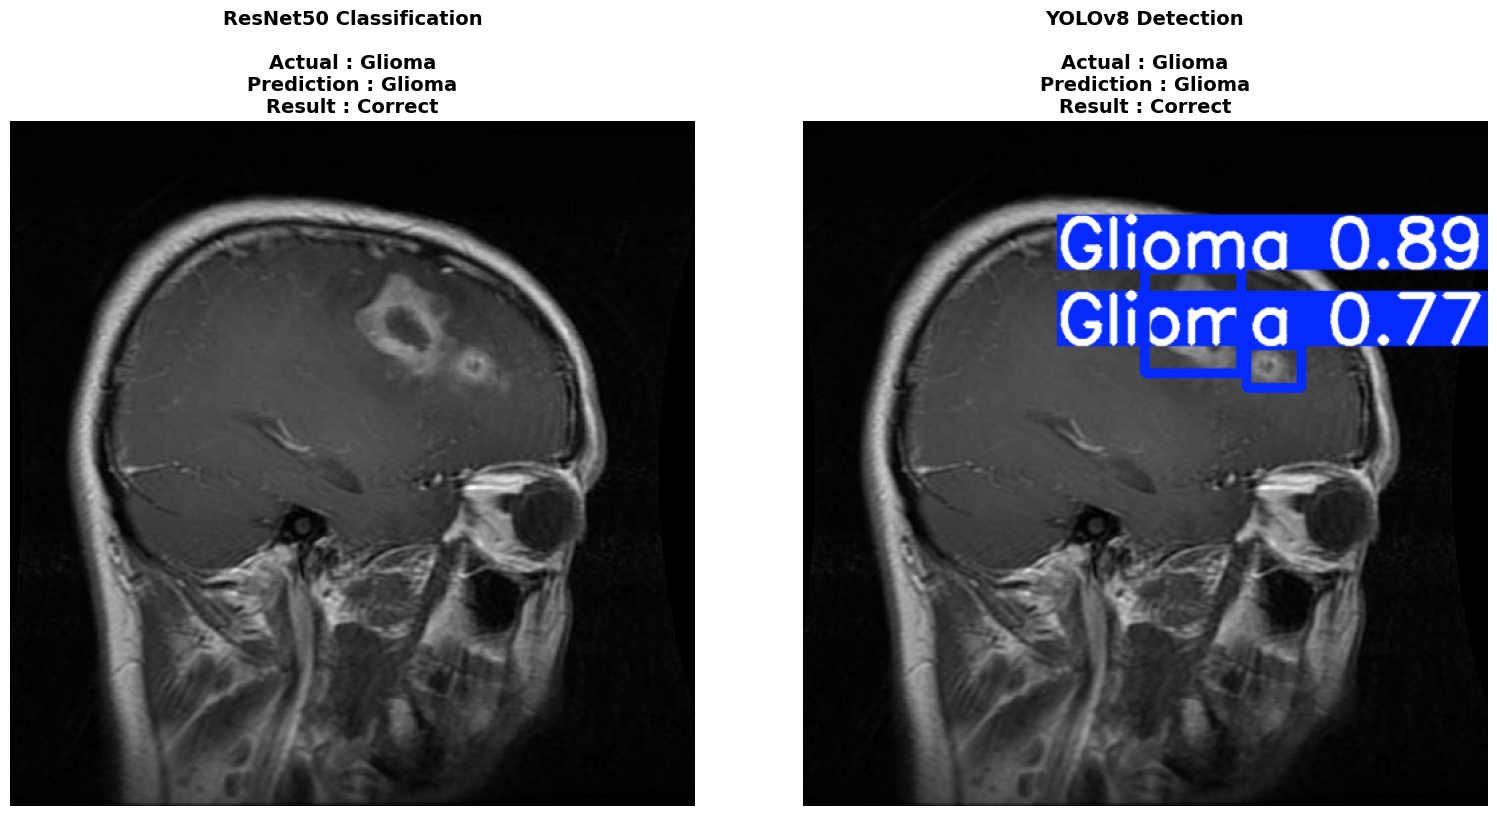

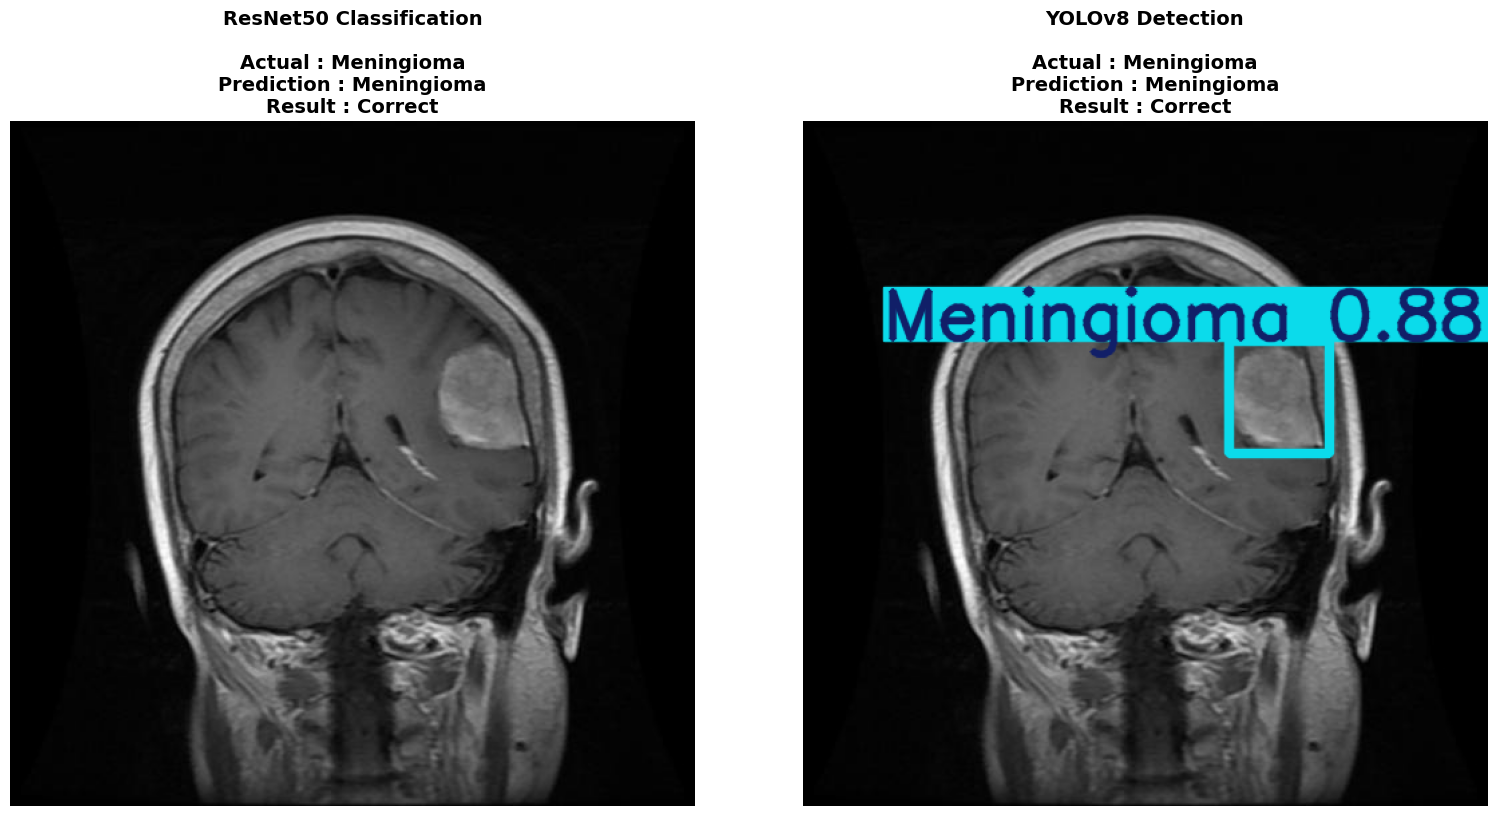

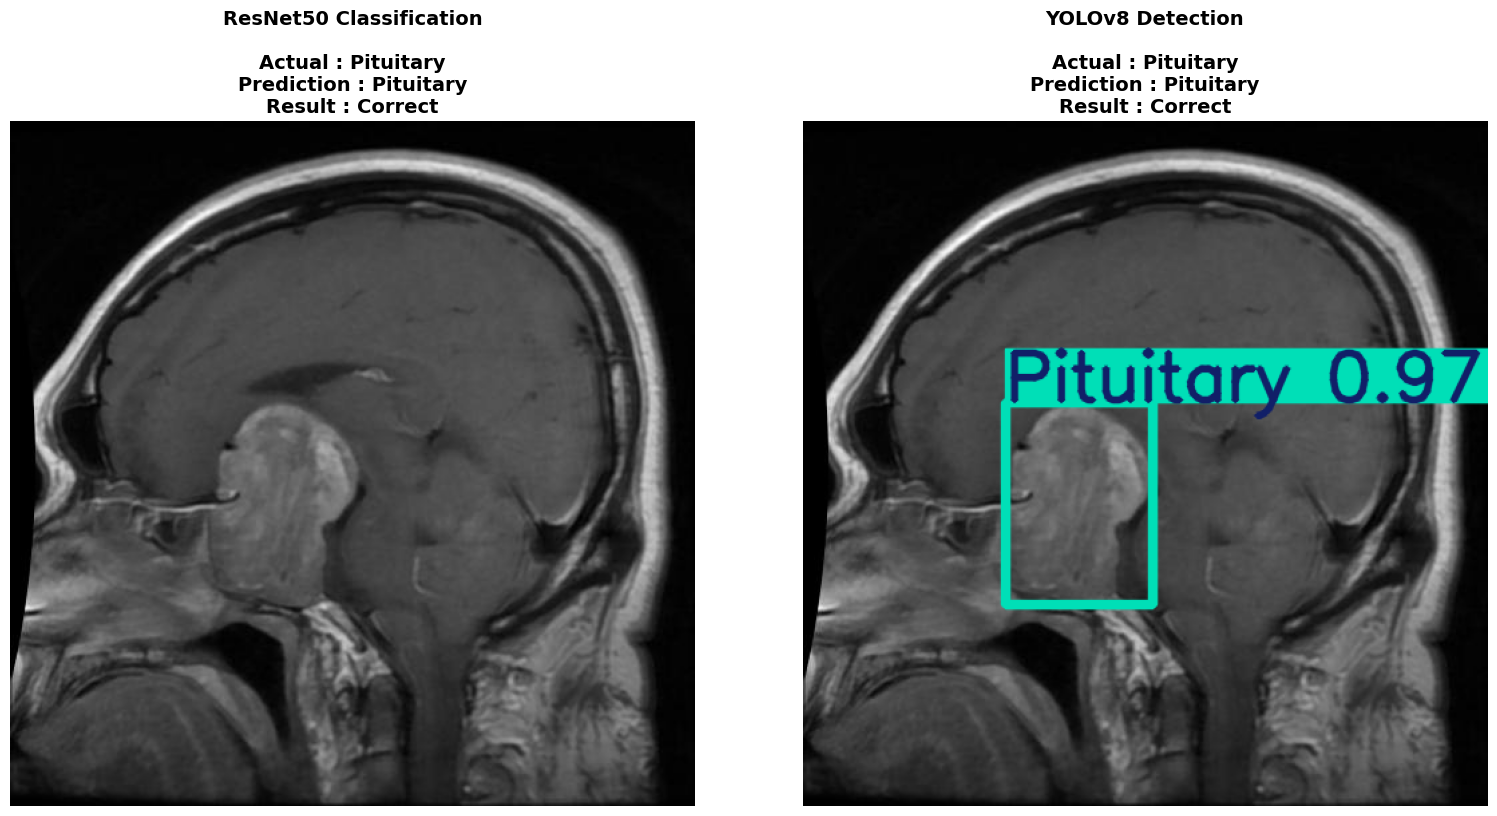

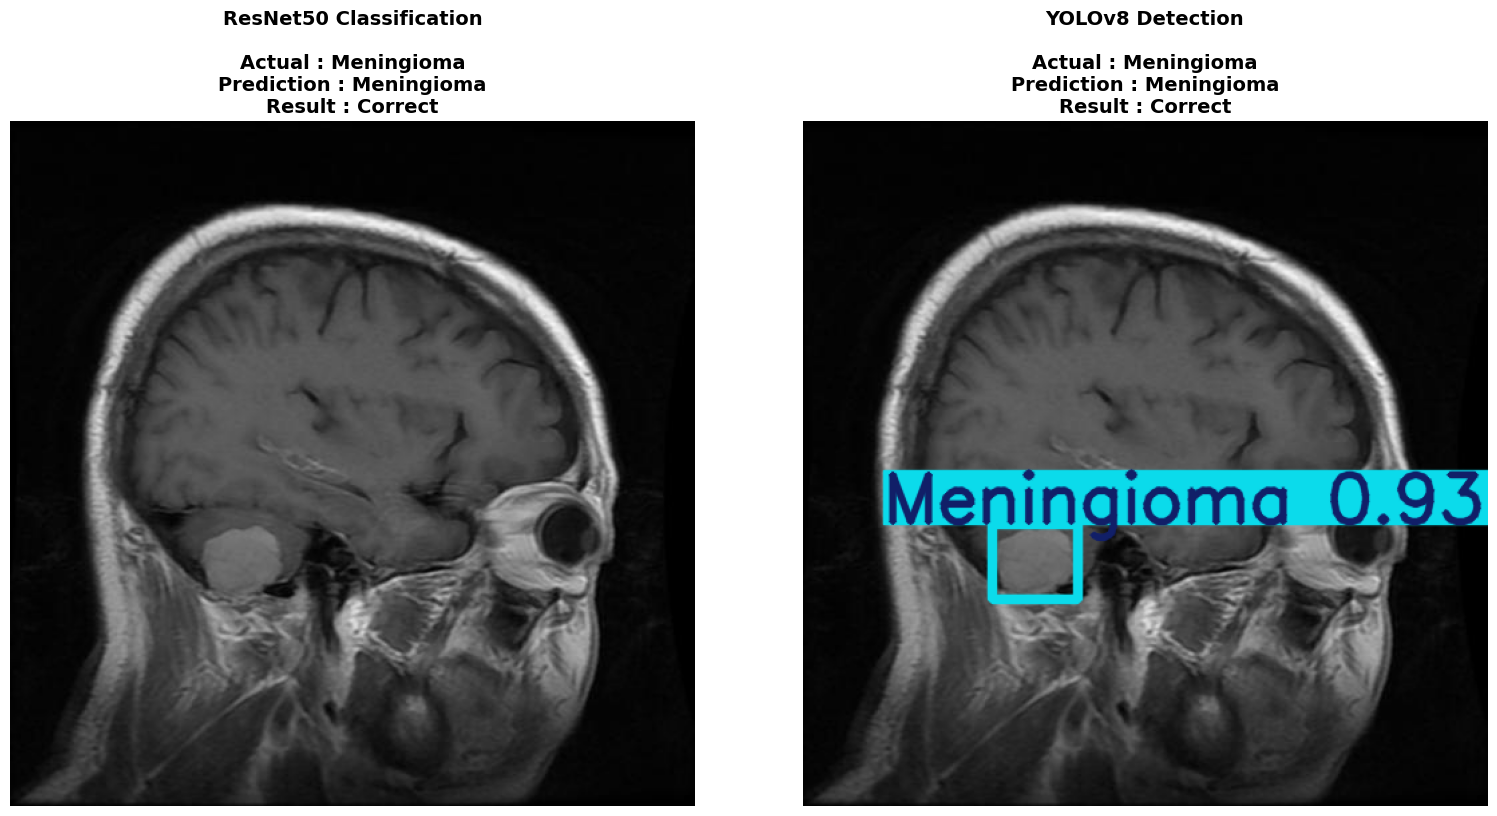

In [ ]:
# ==========================================
# HD VISUAL COMPARISON:
# RESNET50 VS YOLOV8
# ==========================================

sample_indices = random.sample(range(len(test_paths)), 5)

for idx in sample_indices:

    img_path = test_paths[idx]

    actual_class = idx_to_label[y_test[idx]]

    # ======================================
    # LOAD ORIGINAL IMAGE
    # ======================================
    img = cv2.imread(img_path)

    img_rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    # ======================================
    # RESNET50 PREDICTION
    # ======================================
    resnet_class = idx_to_label[resnet_pred[idx]]

    resnet_result = (
        "Correct"
        if actual_class == resnet_class
        else "Wrong"
    )

    # ======================================
    # YOLO PREDICTION
    # ======================================
    yolo_result = best_yolo.predict(
        source=img_path,
        conf=0.25,
        verbose=False
    )[0]

    yolo_img = yolo_result.plot(
        line_width=5,
        font_size=18
    )

    yolo_img = cv2.cvtColor(
        yolo_img,
        cv2.COLOR_BGR2RGB
    )

    yolo_class = idx_to_label[yolo_pred[idx]]

    yolo_result_text = (
        "Correct"
        if actual_class == yolo_class
        else "Wrong"
    )

    # ======================================
    # BIG FIGURE
    # ======================================
    fig, axes = plt.subplots(
        1,
        2,
        figsize=(16, 8)
    )

    # ======================================
    # LEFT = ORIGINAL MRI
    # ======================================
    axes[0].imshow(
        img_rgb,
        cmap="gray"
    )

    axes[0].set_title(
        f"ResNet50 Classification\n\n"
        f"Actual : {actual_class}\n"
        f"Prediction : {resnet_class}\n"
        f"Result : {resnet_result}",
        fontsize=14,
        fontweight="bold"
    )

    axes[0].axis("off")

    # ======================================
    # RIGHT = YOLO DETECTION
    # ======================================
    axes[1].imshow(yolo_img)

    axes[1].set_title(
        f"YOLOv8 Detection\n\n"
        f"Actual : {actual_class}\n"
        f"Prediction : {yolo_class}\n"
        f"Result : {yolo_result_text}",
        fontsize=14,
        fontweight="bold"
    )

    axes[1].axis("off")

    plt.tight_layout()

    plt.show()

Total Wrong Predictions: 35


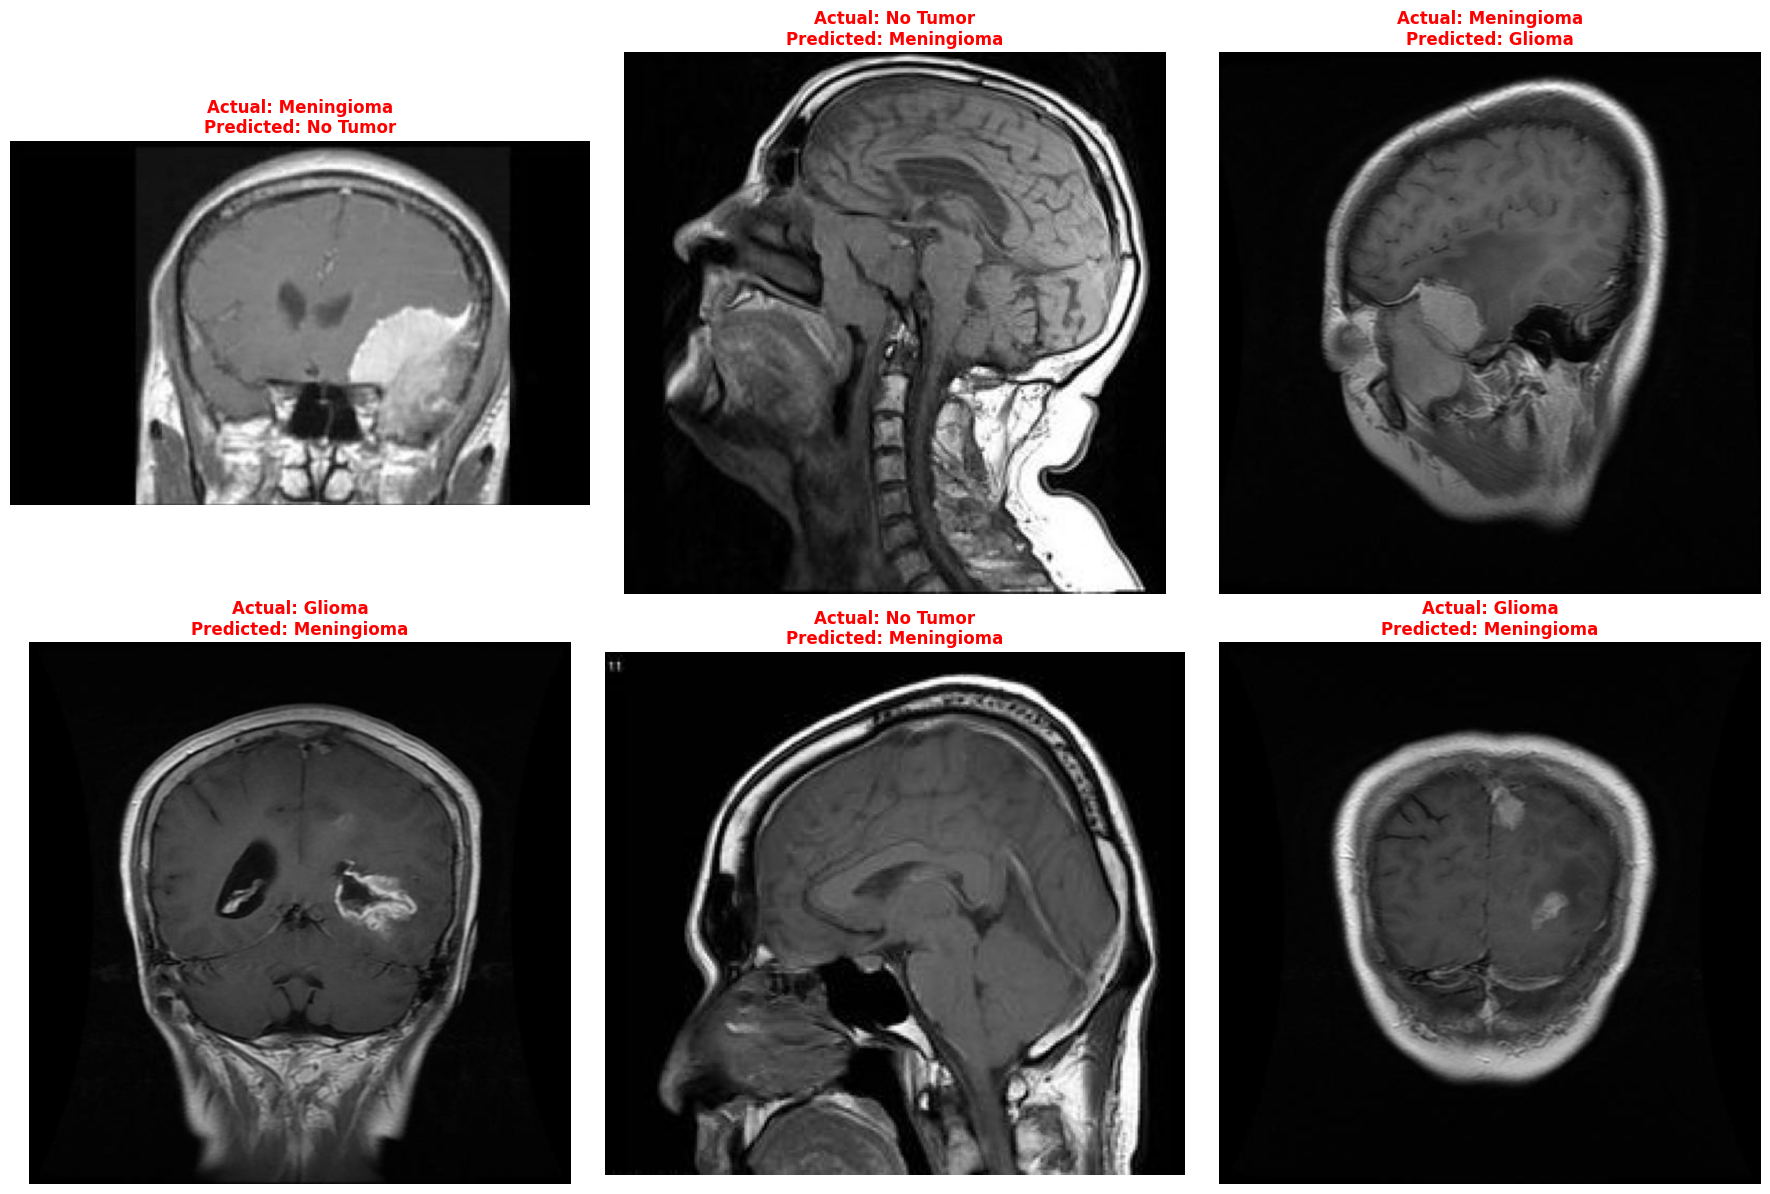

In [ ]:
# ==========================================
# WRONG PREDICTION ANALYSIS
# ==========================================

wrong_indices = np.where(
    resnet_pred != y_test
)[0]

print("Total Wrong Predictions:", len(wrong_indices))

sample_wrong = random.sample(
    list(wrong_indices),
    min(6, len(wrong_indices))
)

plt.figure(figsize=(18, 12))

for i, idx in enumerate(sample_wrong):

    img_path = test_paths[idx]

    img = cv2.imread(img_path)

    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    actual_class = idx_to_label[y_test[idx]]

    predicted_class = idx_to_label[resnet_pred[idx]]

    plt.subplot(2, 3, i + 1)

    plt.imshow(img)

    plt.title(
        f"Actual: {actual_class}\n"
        f"Predicted: {predicted_class}",
        fontsize=12,
        fontweight="bold",
        color="red"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

Total Wrong YOLO Predictions: 21


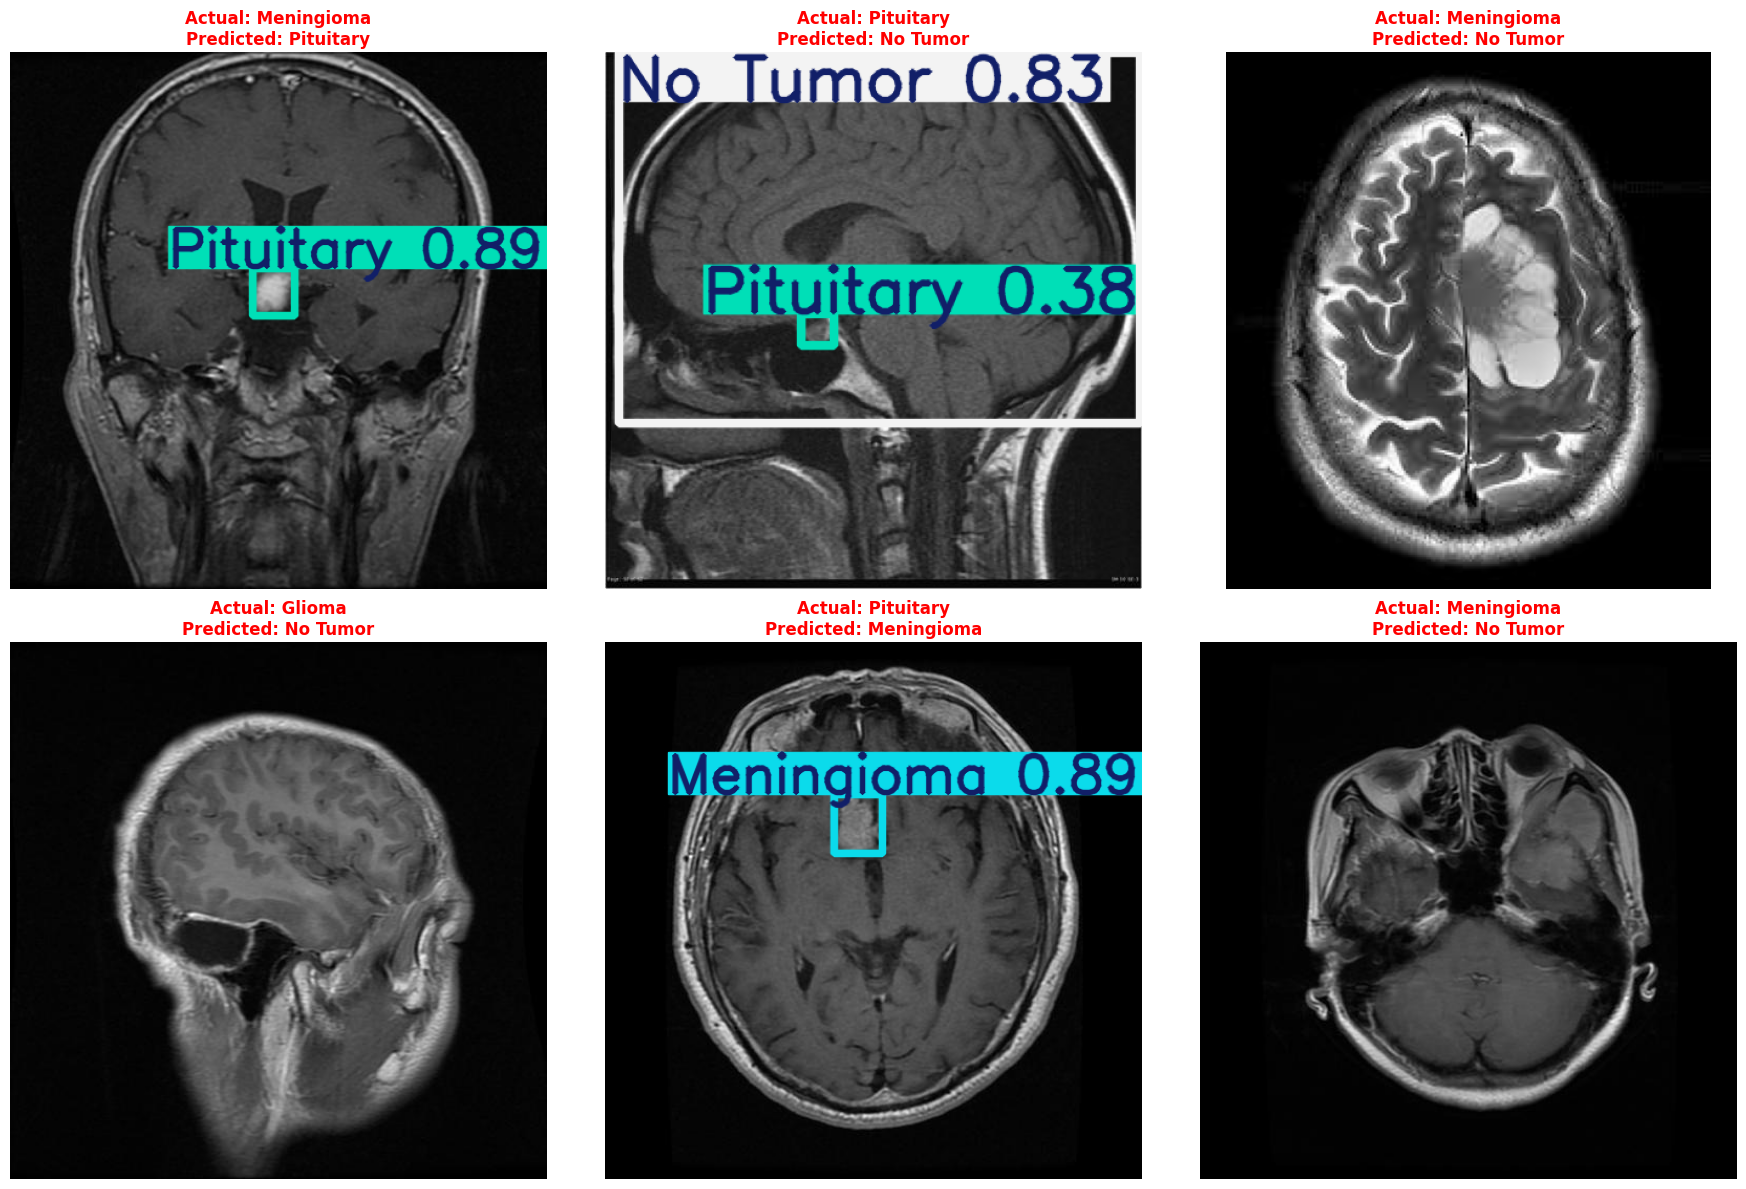

In [ ]:
# ==========================================
# YOLO WRONG PREDICTIONS
# ==========================================

wrong_yolo_indices = np.where(
    yolo_pred != y_test
)[0]

print("Total Wrong YOLO Predictions:", len(wrong_yolo_indices))

sample_wrong_yolo = random.sample(
    list(wrong_yolo_indices),
    min(6, len(wrong_yolo_indices))
)

plt.figure(figsize=(18, 12))

for i, idx in enumerate(sample_wrong_yolo):

    img_path = test_paths[idx]

    actual_class = idx_to_label[y_test[idx]]

    predicted_class = idx_to_label[yolo_pred[idx]]

    # ======================================
    # YOLO DETECTION RESULT
    # ======================================
    yolo_result = best_yolo.predict(
        source=img_path,
        conf=0.25,
        verbose=False
    )[0]

    yolo_img = yolo_result.plot(
        line_width=5,
        font_size=18
    )

    yolo_img = cv2.cvtColor(
        yolo_img,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2, 3, i + 1)

    plt.imshow(yolo_img)

    plt.title(
        f"Actual: {actual_class}\n"
        f"Predicted: {predicted_class}",
        fontsize=12,
        fontweight="bold",
        color="red"
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

In [ ]:
# ==========================================
# FEATURE PREPARATION FOR NAIVE BAYES
# ==========================================
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import cv2

NB_IMG_SIZE = (64, 64)

def load_images_for_nb(image_paths, img_size=(64, 64)):
    X = []

    for img_path in image_paths:
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img = cv2.resize(img, img_size)

        # normalisasi 0-1
        img = img / 255.0

        # flatten jadi 1 dimensi
        img = img.flatten()

        X.append(img)

    return np.array(X)

X_train_nb = load_images_for_nb(train_paths, NB_IMG_SIZE)
X_test_nb = load_images_for_nb(test_paths, NB_IMG_SIZE)

print("Naive Bayes Train Feature:", X_train_nb.shape)
print("Naive Bayes Test Feature :", X_test_nb.shape)

Naive Bayes Train Feature: (4199, 4096)
Naive Bayes Test Feature : (1050, 4096)


In [ ]:
# ==========================================
# TRAIN GAUSSIAN NAIVE BAYES
# ==========================================
from sklearn.naive_bayes import GaussianNB
import time

start_time = time.time()

nb_model = GaussianNB()

nb_model.fit(
    X_train_nb,
    y_train
)

nb_training_time = time.time() - start_time

print("Gaussian Naive Bayes Training Time:", round(nb_training_time, 4), "seconds")

Gaussian Naive Bayes Training Time: 0.2197 seconds


In [ ]:
# ==========================================
# FUNCTION: METRIC EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

from sklearn.preprocessing import label_binarize

def calculate_specificity(y_true, y_pred):

    cm = confusion_matrix(y_true, y_pred)

    specificity_list = []

    for i in range(len(cm)):

        TP = cm[i, i]

        FN = np.sum(cm[i, :]) - TP

        FP = np.sum(cm[:, i]) - TP

        TN = np.sum(cm) - (TP + FN + FP)

        specificity = TN / (TN + FP + 1e-7)

        specificity_list.append(specificity)

    return np.mean(specificity_list)


def get_result_dict(
    model_name,
    y_true,
    y_pred,
    y_prob
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    specificity = calculate_specificity(
        y_true,
        y_pred
    )

    y_true_bin = label_binarize(
        y_true,
        classes=[0, 1, 2, 3]
    )

    roc_auc = roc_auc_score(
        y_true_bin,
        y_prob,
        multi_class="ovr"
    )

    return {

        "Model": model_name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1-Score": f1,

        "Specificity": specificity,

        "ROC-AUC": roc_auc
    }

In [ ]:
# ==========================================
# EVALUATE GAUSSIAN NAIVE BAYES
# ==========================================
nb_pred = nb_model.predict(X_test_nb)
nb_prob = nb_model.predict_proba(X_test_nb)

nb_result = get_result_dict(
    "Gaussian Naive Bayes",
    y_test,
    nb_pred,
    nb_prob
)

display(pd.DataFrame([nb_result]))

,Model,Accuracy,Precision,Recall,F1-Score,Specificity,ROC-AUC
0,Gaussian Naive Bayes,0.56,0.585665,0.56,0.517338,0.853385,0.745548


In [ ]:
# ==========================================
# FINAL COMPARISON TABLE - FULL SAFE VERSION
# ==========================================

nb_result = get_result_dict(
    "Gaussian Naive Bayes",
    y_test,
    nb_pred,
    nb_prob
)

resnet_result = get_result_dict(
    "ResNet50",
    y_test,
    resnet_pred,
    resnet_prob
)

yolo_result = get_result_dict(
    "YOLOv8",
    y_test,
    yolo_pred,
    yolo_prob
)

df_results = pd.DataFrame([
    nb_result,
    resnet_result,
    yolo_result
])

display(df_results)

,Model,Accuracy,Precision,Recall,F1-Score,Specificity,ROC-AUC
0,Gaussian Naive Bayes,0.560000,0.585665,0.560000,0.517338,0.853385,0.745548
1,ResNet50,0.966667,0.966775,0.966667,0.966614,0.988404,0.997239
2,YOLOv8,0.980000,0.980568,0.980000,0.979991,0.993419,0.987251


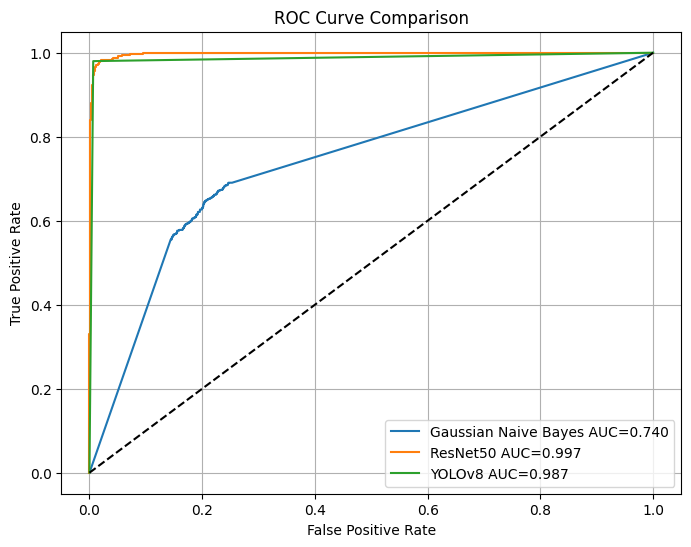

In [ ]:
# ==========================================
# ROC CURVE COMPARISON
# ==========================================
y_true_bin = label_binarize(
    y_test,
    classes=[0, 1, 2, 3]
)

models_prob = {
    "Gaussian Naive Bayes": nb_prob,
    "ResNet50": resnet_prob,
    "YOLOv8": yolo_prob
}

plt.figure(figsize=(8, 6))

for model_name, probs in models_prob.items():

    fpr, tpr, _ = roc_curve(
        y_true_bin.ravel(),
        probs.ravel()
    )

    roc_auc_value = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{model_name} AUC={roc_auc_value:.3f}"
    )

plt.plot([0, 1], [0, 1], "k--")
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()
plt.show()

In [ ]:
# ==========================================
# INFERENCE TIME COMPARISON: GNB vs ResNet50 vs YOLOv8
# ==========================================

import time
import numpy as np
import pandas as pd

sample_paths = list(test_paths[:50])

# ==========================
# WARM-UP RESNET
# ==========================
for img_path in sample_paths[:5]:
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img_array = np.expand_dims(img, axis=0).astype(np.float32)
    img_array = preprocess_input(img_array)
    _ = resnet_model.predict(img_array, verbose=0)

# ==========================
# WARM-UP YOLO
# ==========================
for img_path in sample_paths[:5]:
    _ = best_yolo.predict(
        source=img_path,
        conf=0.25,
        verbose=False
    )

# ==========================
# GAUSSIAN NB INFERENCE TIME
# ==========================
nb_times = []

for img_path in sample_paths:
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.resize(img, NB_IMG_SIZE)
    img = img / 255.0
    img = img.flatten().reshape(1, -1)

    start = time.time()
    _ = nb_model.predict(img)
    end = time.time()

    nb_times.append(end - start)

# ==========================
# RESNET50 INFERENCE TIME
# ==========================
resnet_times = []

for img_path in sample_paths:
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    img_array = np.expand_dims(img, axis=0).astype(np.float32)
    img_array = preprocess_input(img_array)

    start = time.time()
    _ = resnet_model.predict(img_array, verbose=0)
    end = time.time()

    resnet_times.append(end - start)

# ==========================
# YOLOV8 INFERENCE TIME
# ==========================
yolo_times = []

for img_path in sample_paths:
    start = time.time()
    _ = best_yolo.predict(
        source=img_path,
        conf=0.25,
        verbose=False
    )
    end = time.time()

    yolo_times.append(end - start)

# ==========================
# FINAL EFFICIENCY TABLE
# ==========================
df_efficiency = pd.DataFrame({
    "Model": [
        "Gaussian Naive Bayes",
        "ResNet50",
        "YOLOv8"
    ],
    "Average Inference Time (Seconds/Image)": [
        np.mean(nb_times),
        np.mean(resnet_times),
        np.mean(yolo_times)
    ],
    "Min Time": [
        np.min(nb_times),
        np.min(resnet_times),
        np.min(yolo_times)
    ],
    "Max Time": [
        np.max(nb_times),
        np.max(resnet_times),
        np.max(yolo_times)
    ],
    "Capability": [
        "Classification",
        "Classification",
        "Detection + Localization"
    ]
})

display(df_efficiency)

,Model,Average Inference Time (Seconds/Image),Min Time,Max Time,Capability
0,Gaussian Naive Bayes,0.000409,0.000349,0.000598,Classification
1,ResNet50,0.092801,0.088557,0.100798,Classification
2,YOLOv8,0.011079,0.009717,0.018130,Detection + Localization


In [ ]:
# ==========================================
# FINAL COMPARISON TABLE - FIX 3 MODEL
# ==========================================

df_results = pd.DataFrame([
    nb_result,
    resnet_result,
    yolo_result
])

display(df_results)

,Model,Accuracy,Precision,Recall,F1-Score,Specificity,ROC-AUC
0,Gaussian Naive Bayes,0.560000,0.585665,0.560000,0.517338,0.853385,0.745548
1,ResNet50,0.966667,0.966775,0.966667,0.966614,0.988404,0.997239
2,YOLOv8,0.980000,0.980568,0.980000,0.979991,0.993419,0.987251
